# Opening the "Black Box"
## Act III — How does ChatGPT actually work?

**Universidad Panamericana — May 21, 2026** · Eduardo Dueñez, UTSA

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eduenez/public-site/blob/main/2026-UPanamericana-mathAI/notebooks/act3_attention_demo.ipynb)

---

Live demo for **Act III** of the talk. We open the **GPT-2** model (124 M parameters, 2019)
and walk through, step by step:

1. **Words → tokens** — sentence split into sub-word integer IDs.
2. **Tokens → vectors** — each ID indexes into a learned embedding matrix.
3. **Attention** — the one operation that makes transformers work.
4. **Forward pass** — the next-token distribution; sampling continuations.
5. **In-context learning** — the model learns *at inference time* from a few examples.

By the end we land the third **mathematical surprise** of the talk.


---
# 0. Setup

This notebook runs on **Google Colab** and on **local Jupyter**. The first time you run it,
GPT-2 (~500 MB) is downloaded from Hugging Face and cached.

On Apple Silicon we pin BLAS to one thread to avoid an arithmetic-exception crash in some
torch builds.


In [1]:
# @title Runtime setup (run me first)
import os, subprocess, sys

# ── Pin BLAS before importing torch (macOS arithmetic-exception workaround). ─
for var in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
            "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(var, "1")

# ── Colab? Install missing packages. ─────────────────────────────────────
try:
    import google.colab  # noqa: F401
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "transformers"],
        check=False,
    )
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

# Quiet HF Hub chatter.
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(1)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "figure.dpi": 100,
})

print(f"torch {torch.__version__}")
print(f"Running on {'Colab' if _IN_COLAB else 'local Jupyter'}")


torch 2.11.0
Running on local Jupyter


---
# 1. Load GPT-2

GPT-2 (OpenAI, 2019) was the model that put modern transformer LLMs on the map. The smallest
version has **124 million parameters** and is small enough to download and run on any laptop.


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

print("Loading GPT-2 ...")
tok   = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained(
    "gpt2", torch_dtype=torch.float32, attn_implementation="eager",
)
model.eval()
tok.pad_token = tok.eos_token

n_params = sum(p.numel() for p in model.parameters())
print(f"  parameters: {n_params:,}")
print(f"  vocab size: {tok.vocab_size:,}")
print(f"  hidden dim: {model.config.n_embd}")
print(f"  layers:     {model.config.n_layer}")
print(f"  heads/layer:{model.config.n_head}")


Loading GPT-2 ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  parameters: 124,439,808
  vocab size: 50,257
  hidden dim: 768
  layers:     12
  heads/layer:12


---
# 2. Words → tokens

GPT-2's **byte-pair encoding** tokenizer splits text into sub-word units, then assigns each
unit an integer ID. Whitespace matters — leading spaces are encoded as part of the token.

Mathematically: the tokenizer is a (deterministic) function
$$
\text{tok} \colon \text{strings} \longrightarrow \{0, 1, \ldots, V-1\}^{*}
$$
where $V = 50\,257$ is the vocabulary size of GPT-2.


In [3]:
sentence = "The student who solved the problem was happy."

enc    = tok(sentence, return_tensors="pt")
ids    = enc["input_ids"][0].tolist()
tokens = [tok.decode([i]) for i in ids]

print(f"sentence: {sentence!r}\n")
print(f"  {'token':>10s}    id")
print(f"  {'-'*10}   {'-'*5}")
for s, i in zip(tokens, ids):
    print(f"  {s!r:>10s}   {i:5d}")


sentence: 'The student who solved the problem was happy.'

       token    id
  ----------   -----
       'The'     464
  ' student'    3710
      ' who'     508
   ' solved'   16019
      ' the'     262
  ' problem'    1917
      ' was'     373
    ' happy'    3772
         '.'      13


---
# 3. Tokens → vectors (embeddings)

Each token ID indexes into a learned **embedding matrix** $E \in \mathbb{R}^{V \times d}$:

$$
\text{embed}(\text{id}) \;=\; E[\text{id}, \,:\,] \;\in\; \mathbb{R}^{d}.
$$

For GPT-2 small: $V = 50\,257$ rows, $d = 768$ columns. Each row is a "meaning vector" learned
from text. The model's *entire input* is a sequence of such vectors.


In [4]:
E = model.transformer.wte.weight        # (V, d) embedding matrix
print(f"embedding matrix shape: {tuple(E.shape)}")

# Look at the embedding of the token " happy" (with the leading space).
happy_id = tok.encode(" happy", add_special_tokens=False)[0]
v = E[happy_id].detach().numpy()
print(f"\n token ' happy' → id {happy_id}")
print(f"  embedding (first 8 of {len(v)} dims):")
print(f"  {np.array2string(v[:8], precision=3, separator=', ')}")
print(f"  ‖embedding‖₂ = {np.linalg.norm(v):.3f}")


embedding matrix shape: (50257, 768)

 token ' happy' → id 3772
  embedding (first 8 of 768 dims):
  [ 0.09 , -0.099,  0.121, -0.075,  0.177,  0.026, -0.303, -0.015]
  ‖embedding‖₂ = 3.156


---
# 4. Attention — the entire trick

Each transformer layer computes, for the sequence of input vectors $X \in \mathbb{R}^{T \times d}$,
three projections

$$
Q = X W^{Q}, \qquad K = X W^{K}, \qquad V = X W^{V},
$$

and then the **attention output**

$$
\boxed{\;
\text{Attn}(X) \;=\; \text{softmax}\!\Bigl(\tfrac{Q K^{\top}}{\sqrt{d_k}}\Bigr)\, V
\;}
$$

The matrix $A := \text{softmax}\bigl(Q K^{\top}/\sqrt{d_k}\bigr) \in \mathbb{R}^{T \times T}$ is the
**attention pattern**: $A_{ij}$ is how much token $i$ "looks at" token $j$. We display one
such pattern from one head of one layer.


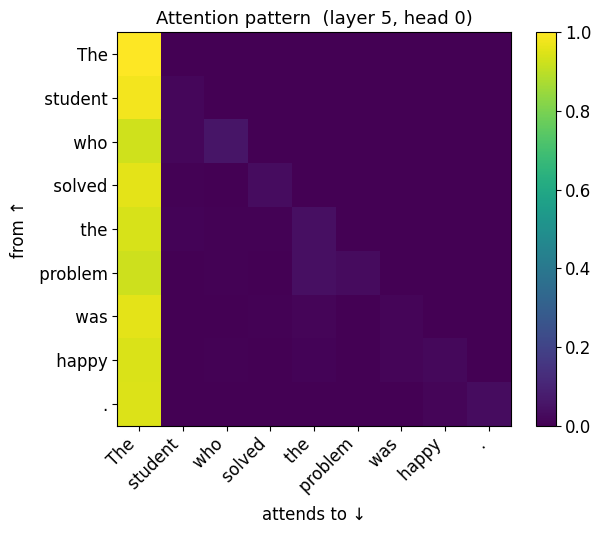

row sums (should all be 1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [5]:
LAYER, HEAD = 5, 0   # any layer/head shows the idea; layer 5 is mid-stack.

with torch.no_grad():
    out = model(**enc, output_attentions=True)
A = out.attentions[LAYER][0, HEAD].cpu().numpy()    # (T, T)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(A, cmap="viridis", vmin=0, vmax=A.max())
ax.set_xticks(range(len(tokens)), tokens, rotation=45, ha="right")
ax.set_yticks(range(len(tokens)), tokens)
ax.set_xlabel("attends to ↓")
ax.set_ylabel("from ↑")
ax.set_title(f"Attention pattern  (layer {LAYER}, head {HEAD})")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

# Row sums to 1 (softmax over the 'attends to' axis).
print(f"row sums (should all be 1): {A.sum(axis=1).round(3)}")


---
# 5. Forward pass → next-token generation

GPT-2 takes a sequence of tokens, runs them through **12 stacked transformer blocks**
(attention + MLP), and outputs a distribution over the **next token**:

$$
p(\text{next token} \mid \text{context}) \;=\; \text{softmax}\bigl(\text{logits}\bigr).
$$

Generation is just **predict-next-token, append, repeat**. We write this loop by hand below.


In [6]:
def generate(prompt, n_new=12, temperature=None, seed=None):
    """Append n_new tokens to prompt by repeated next-token prediction.

    temperature=None → greedy argmax; otherwise sample from softmax(logits/T).
    """
    if seed is not None:
        torch.manual_seed(seed)
    ids = tok(prompt, return_tensors="pt")["input_ids"]
    seed_len = ids.shape[1]
    for _ in range(n_new):
        with torch.no_grad():
            logits = model(ids).logits[0, -1]
        if temperature is None:
            next_id = int(logits.argmax())
        else:
            probs   = torch.softmax(logits / temperature, dim=-1)
            next_id = int(torch.multinomial(probs, 1))
        ids = torch.cat([ids, torch.tensor([[next_id]])], dim=1)
        if next_id == tok.eos_token_id:
            break
    return tok.decode(ids[0][seed_len:], skip_special_tokens=True)

seed_text = "A neural network learns to"
print(f"prompt: {seed_text!r}\n")
print(f"greedy:            {generate(seed_text)!r}")
for k in range(3):
    print(f"sample T=0.9 #{k+1}: {generate(seed_text, temperature=0.9, seed=k)!r}")


prompt: 'A neural network learns to'



greedy:            ' recognize and respond to a stimulus.\n\nThe neural network'


sample T=0.9 #1: ' avoid certain objects with a certain level of "tree-like'


sample T=0.9 #2: ' recognize a shape in the 2D space. After neuron activity'


sample T=0.9 #3: ' write to an application that it knows how to use. This'


---
# 6. In-context learning — *learning at inference time*

Nothing has changed about the model's weights. Yet if we put a few **examples** in the prompt,
the model learns the pattern and continues it. Let's see what GPT-2 (small) can and can't do.


In [7]:
probes = [
    ("hot : cold\nbig : small\nday : ",                "opposites"),
    ("Spain : Madrid\nFrance : Paris\nMexico : ",       "capitals"),
    ("cat -> 4\ndog -> 4\nspider -> ",                  "leg counts"),
]
for prompt, label in probes:
    completion = generate(prompt, n_new=4)
    print(f"--- {label} ---")
    print(f"  prompt:     {prompt!r}")
    print(f"  completion: {completion!r}")
    print()


--- opposites ---
  prompt:     'hot : cold\nbig : small\nday : '
  completion: '\xa0night\nday'



--- capitals ---
  prompt:     'Spain : Madrid\nFrance : Paris\nMexico : '
  completion: '\xa0Madrid\n'



--- leg counts ---
  prompt:     'cat -> 4\ndog -> 4\nspider -> '
  completion: '~~~\n\n'



---
# 🎉 Surprise #3 — In-Context Learning

GPT-2 (124 M params, 2019) handles the **opposites** pattern but fails on **capitals** and
**leg counts**. The bigger Llama 3.2 (3 B params) we saw at the start of the talk handles all
three. *That's what scaling buys you.*

The astonishing part is that **the model learned to learn at inference time**, with
**no weight update**:

> Given a few input–output pairs in the prompt, the model infers the pattern and applies it.

This was not designed in. It **emerged** in models above a certain size.

> **Empirically (Garg et al. 2022; Akyürek et al. 2023).**
> Transformers trained on language data appear to run *gradient-descent-like* algorithms inside
> their forward pass. The model implicitly fits a function to the in-context examples and
> applies it to the query — entirely in activations, with the weights held fixed.

We do **not have a complete theory** of why this happens. It is one of the most active areas of
current research.

> **Sutton's Bitter Lesson (2019).**
> General methods that leverage **scale of data + scale of compute** consistently beat clever,
> hand-crafted inductive biases. In-context learning is one big demonstration of this.

The three surprises of this talk:

1. **Universal approximation** — neural networks *can* represent anything.
2. **Double descent** — making them bigger past the interpolation threshold *helps*.
3. **In-context learning** — large transformers *learn* without changing a weight.

The mathematics of points 2 and 3 is **still being worked out**. *You* could work on it.
